In [19]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "kwill580"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

#today_dir = "Assignments/MidtermExam"
#os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

✅ Already inside repo folder: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/kwill580/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design


# STAT 7220 - Midterm Exam
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: March 20, 2026**

**PART 1 INSTRUCTIONS:** Suppose you are a video game controller manufacturer interested in estimating the perceived comfort level of controller grips. To achieve this, you decide to conduct an experiment to assess different material types used for the controller grips (plastic, rubber, silicone, and metal). 10 prototypes of each grip type are manufactured and given to professional gamers (who all play the same game -- Apex Legends) to test. The gamers use the controllers regularly for one month and then rate the comfort level on a scale from 1 - 10 with greater scores indicating a greater level of perceived comfort (one decimal allowed). The data from this experiment are stored in the Video Game Controllers.xlsx file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment
* The objective of this experiment is to determine which material for controller grips are the most comfortable.

**Question 2.** Specify the outcome variable
* The outcome variable is comfort, which is a continuous numeric variable.  

**Question 3.** Specify the independent variable. What are some possible lurking variables?
* Independent variable: Material which is a nominal categorical variable with 4 different options (plastic, rubber, silicone, and metal).
* A possible lurking factor could be gamers are more generous or harsh with their comfort ratings. Another factor would is being unsure how long, in one gaming session or in total, the gamer used the controller during the trial month to give the comfort rating.

**Question 4.** Briefly explain why a completely randomized design may be appropriate for this experiment.
* Since our experimental units are  homogeneous, and all other elements of our experiment are supposed to be as consistent, we are able to
use randomization and replication to focus on the difference in treatment effect.

**Question 5.** State the null and alternative hypotheses for this experiment.

$$ \begin{align}
H_0&: \mu_{\text{plastic}} = \mu_{\text{rubber}} = \mu_{\text{silicone}}= \mu_{\text{metal}} \\
H_1&: \text{At least one group mean is different}
\end{align}
$$

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Material  40 non-null     object 
 1   Comfort   40 non-null     float64
dtypes: float64(1), object(1)
memory usage: 772.0+ bytes
None
          mean       std
Material                
Metal     5.39  0.877433
Plastic   5.93  0.620125
Rubber    6.23  0.702456
Silicone  7.63  0.700872


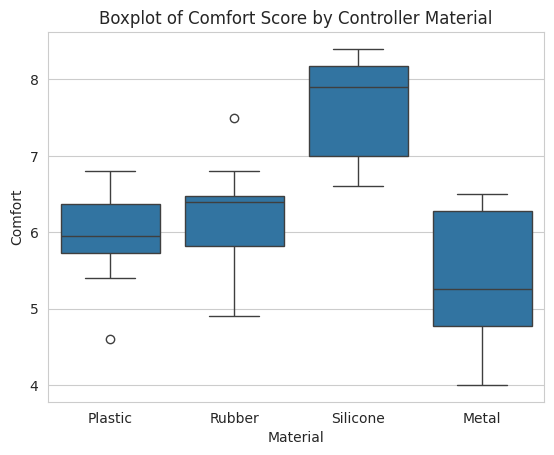

In [20]:
## Import Necessary Python Packages ##
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

##Import the Video Game Data ##

videogame_data = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/Midterm-Exam/Video Game Controllers.xlsx")

## Data Integrity Check with .info ##

print(videogame_data.info())

## Calculate Mean and Standard Deviation
## of Comfort by Material ##

videogame_stats = videogame_data.groupby('Material')['Comfort'].agg(['mean','std'])

print(videogame_stats) # Corrected variable name from videogame_stats to Comfort
## Generate Boxplot for Visual Comparison ##

## Set style (default is "darkgrid") ##

sns.set_style("whitegrid")
## Create boxplot ##

sns.boxplot(x="Material",y="Comfort",data=videogame_data)

## Add Title and Labels ##

plt.title("Boxplot of Comfort Score by Controller Material", loc='center')
plt.xlabel("Material")
plt.ylabel("Comfort")
plt.show()


*  As shown in both the table of summary statistics as well as the boxplots, silicone has a higher mean comfort rating than the other materials. The table of summary statitics and the boxplots, present similar in value means between plastic and rubber, which is also higher than metal. This evidence lends towards the the alternative hypothesis.

**Question 7.** Build a one-way ANOVA model. Test the assumption of normality using **both** a testing and visual method. Do the results of the normality test(s) support the assumption of normality?

In [21]:
## Fit One-Way ANOVA Model ##

videogame_mod = ols("Comfort~Material",data=videogame_data).fit()

In [22]:
## Perform Shapiro-Wilk Test of Normality ##
from scipy.stats import shapiro

residuals = videogame_mod.resid
sw_test = shapiro(residuals)

## Extract Test Stat and P-Value ##
sw_stat = sw_test.statistic
sw_pvalue = sw_test.pvalue

## Print Results ##
print(f"Shapiro-Wilk Test Statistic: {sw_stat:.4f}")
print(f"Shapiro-Wilk Test P-Value: {sw_pvalue:.4f}")
if sw_pvalue > 0.05:
    print("Fail to reject null hypothesis: Residuals are normally distributed.")
else:
    print("Reject null hypothesis: Residuals are not normally distributed.")

Shapiro-Wilk Test Statistic: 0.9710
Shapiro-Wilk Test P-Value: 0.3874
Fail to reject null hypothesis: Residuals are normally distributed.


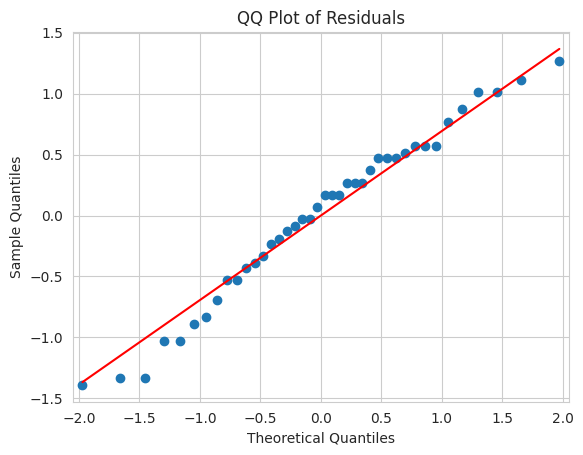

In [23]:
## Generate QQ plot using seaborn ##

sm.qqplot(residuals, line ='s')
plt.title("QQ Plot of Residuals")
plt.show()

* The QQ-plot displays only a couple of exceptions, all of the
points fall very closely to the diagonal line. The Shapiro-Wilk test has a p-value of 0.39, which would indicate that the data supports
the null hypothesis and the assumption of normality is met.

**Question 8.** Test the assumption of homogeneity of variance using **both** a testing and visual method. Do the results of the test(s) support the assumption of homogeneity of variance?

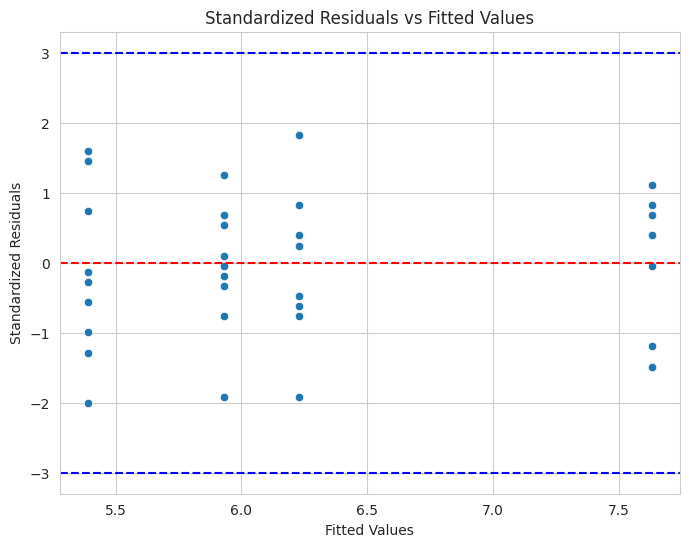

BP Test F-statistic: 0.684288131275624
BP Test F p-value: 0.5674916917969977
Fail to reject null hypothesis: Homoscedasticity detected. Constant Variance assumed.


In [24]:
## Obtain Standardized Residuals ##

vg_standardized_residuals = videogame_mod.get_influence().resid_studentized_internal

## Get the fitted values ##

vg_fitted_values = videogame_mod.fittedvalues

## Create the plot using seaborn ##

plt.figure(figsize=(8,6))
sns.scatterplot(x=vg_fitted_values, y=vg_standardized_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(3, color='blue', linestyle='--')
plt.axhline(-3, color='blue', linestyle='--')
plt.title("Standardized Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

## Import necessary function: ##

from statsmodels.stats.diagnostic import het_breuschpagan

## Run B-P Test ##

vg_bp_test = het_breuschpagan(videogame_mod.resid,videogame_mod.model.exog)

## Extract F-statistic ##

f_statistic = vg_bp_test[2]

## Extract its P-Value ##

f_p_value = vg_bp_test[3]

print(f"BP Test F-statistic: {f_statistic}")
print(f"BP Test F p-value: {f_p_value}")
if f_p_value > 0.05:
    print("Fail to reject null hypothesis: Homoscedasticity detected. Constant Variance assumed.")
else:
    print("Reject null hypothesis: Heteroscedasticity detected. Constant Variance not assumed.")


* The scatterplot of standardized residuals versus fitted values doesn't show anympoints are less than -3 or greater than +3. The residual points are randomly scattered about 0 while the heights of the vertical lines,  are approximately equal.
The visual thus support the assumption of constant variance.
* The B-P test has yielded a
p-value of 0.57 which is greater than our typically used thereshold of 0.05. Since the test lends
support for the null hypothesis of constant variance. This evidence supports that the sample data met the constant variance assumption.

**Question 9.** Report the F-statistic and its associated p-value for the test for the treatment factor. Which of our two hypotheses is more strongly supported? Why?

In [25]:
## Print ANOVA Table Adding Significance Column ##

tab = sm.stats.anova_lm(videogame_mod,typ=1)

tab["Significant"] = np.where(tab["PR(>F)"]<0.05,"Yes","No")

print(tab)

            df  sum_sq   mean_sq          F        PR(>F) Significant
Material   3.0  27.387  9.129000  17.070642  4.616153e-07         Yes
Residual  36.0  19.252  0.534778        NaN           NaN          No


* From our omnibus test, we can see that we have F(3, 36) = 17.07 with an associated p-value
that is less than alpha = 0.05. This indicates that the data more strongly support that alternative
hypothesis that at least two group means differ substantially from each other.


**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which material types are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2  meandiff p-adj   lower  upper  reject
------------------------------------------------------
  Metal  Plastic     0.54 0.3639 -0.3408 1.4208  False
  Metal   Rubber     0.84 0.0662 -0.0408 1.7208  False
  Metal Silicone     2.24    0.0  1.3592 3.1208   True
Plastic   Rubber      0.3 0.7958 -0.5808 1.1808  False
Plastic Silicone      1.7    0.0  0.8192 2.5808   True
 Rubber Silicone      1.4 0.0007  0.5192 2.2808   True
------------------------------------------------------


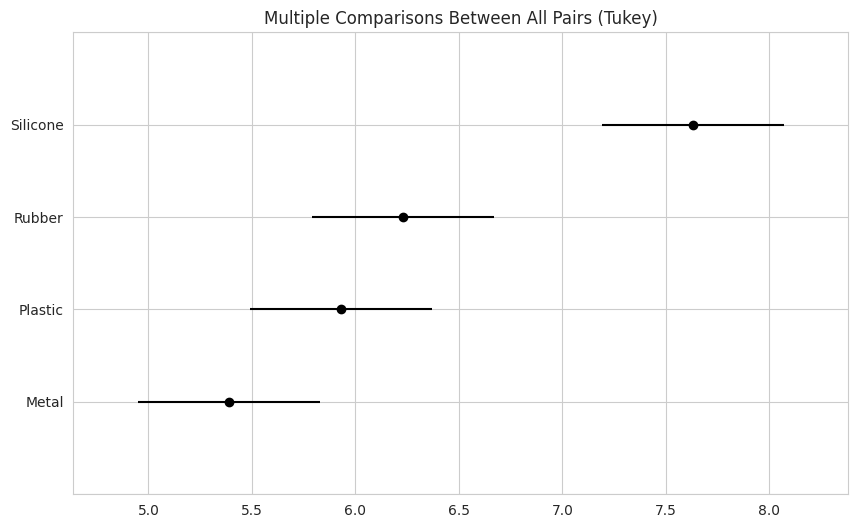

In [26]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Perform Tukey's HSD test ##

vg_tukey_result = pairwise_tukeyhsd(endog=videogame_data['Comfort'], groups=videogame_data['Material'],
                                 alpha=0.05)

## Print Tukey Visualization ##

vg_tukey_result.plot_simultaneous()

## Print Tukey Table ##

print(vg_tukey_result)

* The results of Tukey's HSD post-hoc test indicate that mean comfort between silicone and the other three materials are statisically
different. Mean comfort rating between plastic, rubber, and metal were not found to be
statistically different from each other.

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses. Additionally, include potential limitations of this experiment and suggestions for future experimentation.

* Overall we performed an experiment comparing the comfort level of four different material types to make game controller grips.Professional gamers  played the same game, and used the controller regualrly report a comfort level on a scale from 1 - 10, after one month. Descriptive analyses supported the hypothesis that a meaningful difference would exist, between at least one of the material types. The difference was further supported by the validated omnibus F-test. The post-hoc analysis determined that all group means besides silicone were the same. Silicone yielded the highest comfort rating between the foour materials.
* One limiation of this study is that we assumed the professional gamers use the controllers for the same amount of time in each time they used it. We might also need to consider personal sensitivity to each material. In the future we could make sure the gaming sessions are timed.


**PART 2 INSTRUCTIONS:** The same video game controller manufacturing company is now trying to get into the business of creating virtual reality/artificial intelligence content for education. Specifically, they want to build a VR experience to simulate working with elderly patients at a healthcare facility to better prepare nursing students for potential careers in working with elderly patients. To test the VR's effectiveness, a group of 40 undergraduate nursing students were randomly and equally assigned to either a class session utilizing the VR or a class session using a traditional technique for teaching strategies for working with elderly patients. At the end of the class session, a 50 question quiz was given to both groups which measures attitudes toward elderly people. Scores range from 0-50 with greater scores indicating more favorable attitudes toward elderly people and vice versa. However, some students in the group have had prior working experience with elderly people which may have an effect on the quiz outcome. So in the experiment, we document which students have had prior working experience with elderly people and which haven't. The results of the experiment are contained in the `Nursing VR Study.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

* The objective of this experiment is to compare the mean quiz scores between the students that used the VR experience and the students with traditional teaching while controlling for prior work experience with elderly patients.

**Question 2.** Specify the outcome variable
* The outcome variable is the percentage score on the 50-question quiz, which is a quantitative,
continuous variable.

**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?
* IV: Method is a nominal, categorical variable (VR or Traditional)
• Blocking Factor: Experience is a nominal, categorical variable with two levels
(Prior experience and no prior experience)
• Possible Lurking Variables: Prior working experience or prior favorable attitudes towards elderly patients, and student motivation  


**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.

* A randomized block design would be appropriate here because it allows us to control for
the potential confounding effect of prior work experience on quiz scores. By blocking on prior
experience, we can ensure that each teaching style is fairly compared within each level of
prior experience. A completely randomized design would not be appropriate because it would
not account for the variability in prior experience.


**Question 5.** State the null and alternative hypotheses for this experiment.

$$ \begin{align}
H_0&: \mu_{\text{VR}} = \mu_{\text{Traditional}}  \\
H_1&: \text{The group means are different}
\end{align}
$$

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Method      40 non-null     object
 1   Experience  40 non-null     object
 2   Score       40 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.1+ KB
None
             mean       std
Method                     
Traditional  30.8  6.716829
VR           38.5  6.969860


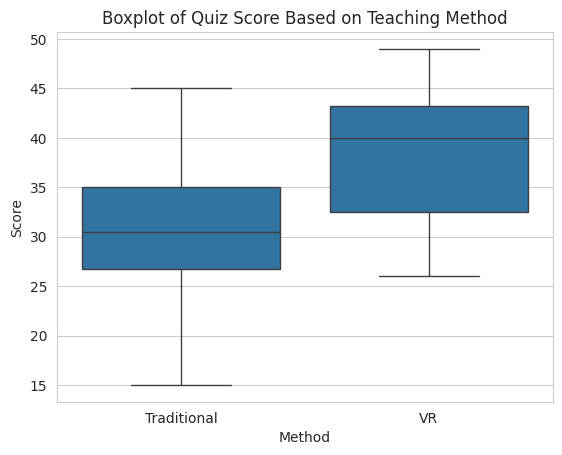

In [27]:
##Import the Nursing VR Data ##

vr_data = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/Midterm-Exam/Nursing VR Study.xlsx")
## Data Integrity Check with .info ##

print(vr_data.info())

## Calculate Mean and Standard Deviation

vr_stats = vr_data.groupby(['Method'])['Score'].agg(['mean','std'])

print(vr_stats)

## Create boxplot ##

sns.boxplot(x="Method",y="Score",data=vr_data)

## Add Title and Labels ##

plt.title("Boxplot of Quiz Score Based on Teaching Method", loc='center')
plt.xlabel("Method")
plt.ylabel("Score")
plt.show()


* The summary statistics show VR to have a higher mean quiz score. The boxplot visualized a slight overlap between traditional and VR teaching, while having a jump in mean. Overall, the results of the descriptive analysis provides support for the alternative hypothesis.

**Question 7.** Build a two-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

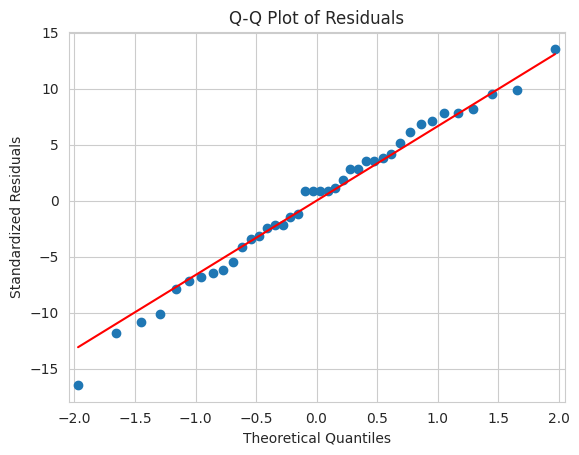

Shapiro-Wilk Test Statistic: 0.987
Shapiro-Wilk P-value: 0.917

Based on the Shapiro-Wilk test (p > 0.05), we fail to reject the null hypothesis of normality. The residuals appear to be normally distributed.


In [28]:
## Fit ANOVA Model ##

vr_mod = ols("Score~Method+Experience",data=vr_data).fit()
## Test the assumption of normality ##
# Get the residuals from the ANOVA model
vr_res = vr_mod.resid

# Visual Method: Q-Q plot
fig = sm.qqplot(vr_res, line='s')
plt.title("Q-Q Plot of Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Standardized Residuals")
plt.show()

# Testing Method: Shapiro-Wilk Test
from scipy.stats import shapiro
shapiro_test = shapiro(vr_res)

print(f"Shapiro-Wilk Test Statistic: {shapiro_test.statistic:.3f}")
print(f"Shapiro-Wilk P-value: {shapiro_test.pvalue:.3f}")

# Interpret the results
alpha = 0.05
if shapiro_test.pvalue > alpha:
    print("\nBased on the Shapiro-Wilk test (p > 0.05), we fail to reject the null hypothesis of normality. The residuals appear to be normally distributed.")
else:
    print("\nBased on the Shapiro-Wilk test (p <= 0.05), we reject the null hypothesis of normality. The residuals do not appear to be normally distributed.")


* All of the points on the Q-Q plot fall along the reference line with very little
deviation. This visual indicating that the residuals are approximately normally distributed and meet the assumption of normality.
The SW-Test have a p-value of 0.91, which is greater than the threshold of 0.05.
Based on the p-value fail to reject the null hypothesis, suggesting that the residuals are
normally distributed.

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

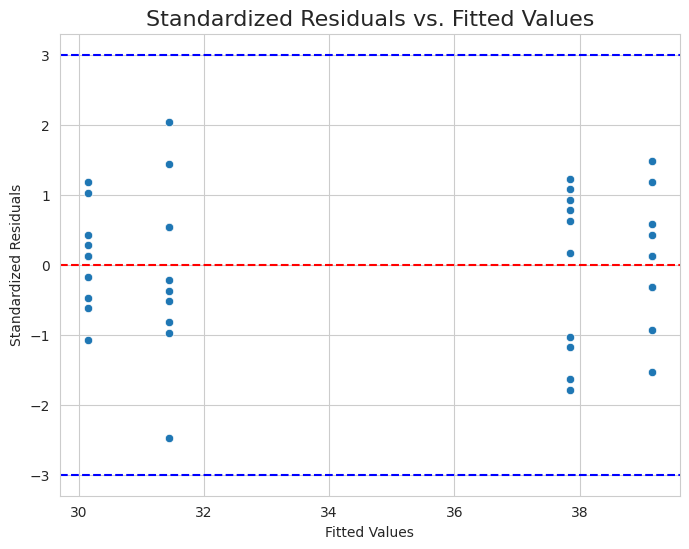

F-statistic: 0.19858503981404418
F p-value: 0.8207581702983743
No heteroscedasticity detected (fail to reject H0). Constant Variance assumed.


In [29]:
## Obtain Standardized Residuals ##

vr_standardized_residuals = vr_mod.get_influence().resid_studentized_internal

## Get the fitted values ##

vr_fitted_values = vr_mod.fittedvalues

## Create the plot using seaborn ##

plt.figure(figsize=(8,6))
sns.scatterplot(x=vr_fitted_values, y=vr_standardized_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(3, color='blue', linestyle='--')
plt.axhline(-3, color='blue', linestyle='--')
plt.title("Standardized Residuals vs. Fitted Values", fontsize=16)
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

## B-P Test ##

## Import necessary function: ##

from statsmodels.stats.diagnostic import het_breuschpagan

## Run B-P Test ##

vr_bp_test = het_breuschpagan(vr_mod.resid,vr_mod.model.exog)

## Extract F-statistic ##

vrf_statistic = vr_bp_test[2]

## Extract its P-Value ##

vr_f_p_value = vr_bp_test[3]

print(f"F-statistic: {vrf_statistic}")
print(f"F p-value: {vr_f_p_value}")
if f_p_value < 0.05:
    print("Heteroscedasticity detected (reject H0). Constant Variance not assumed.")
else:
    print("No heteroscedasticity detected (fail to reject H0). Constant Variance assumed.")

* The scatterplot displays randomly scattered points around zero, while being between +3 and -3. The height of the vertical lines are roughly similar. The p-value from the BP test is 0.82, which is greater than 0.05. Both the visual and statistical evidence supports that the assumption of homoscedasticity has been met.

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?


In [30]:
## Obtain ANOVA Table ##

vr_tab = sm.stats.anova_lm(vr_mod,typ=2)

## Add Significance Column ##

vr_tab["Significance"] = np.where(vr_tab["PR(>F)"]<0.05,"Significant","Not Significant")

print(vr_tab)

            sum_sq    df          F    PR(>F)     Significance
Method       592.9   1.0  12.441048  0.001140      Significant
Experience    16.9   1.0   0.354619  0.555135  Not Significant
Residual    1763.3  37.0        NaN       NaN  Not Significant


* The F-statistic associated with this treatment effect (F(1,37)=12.44, p= 0.001), is significant. The results from the ANOVA table indicate there is a difference in means of the treatment groups, supporting the alternative hypothesis.

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

Figure(1000x600)
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
   group1   group2 meandiff p-adj lower   upper  reject
-------------------------------------------------------
Traditional     VR      7.7 0.001 3.3184 12.0816   True
-------------------------------------------------------


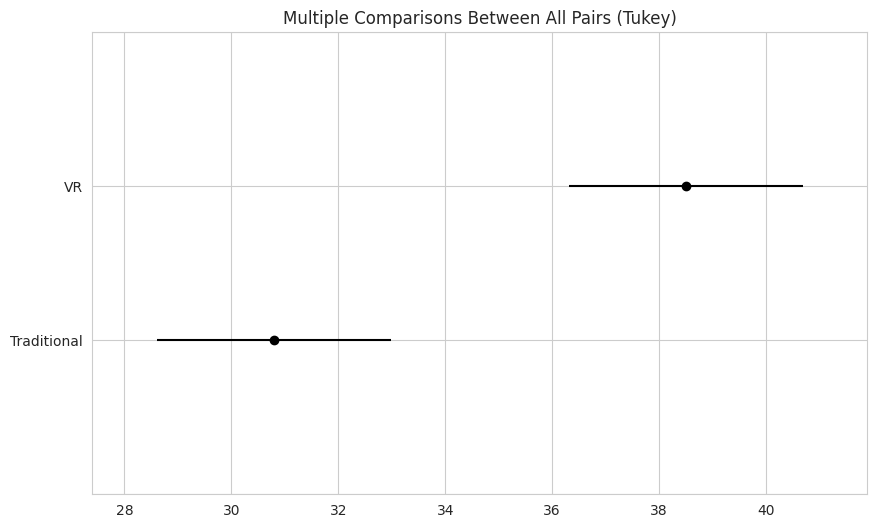

In [31]:
vr_tukey_result = pairwise_tukeyhsd(endog=vr_data['Score'], groups=vr_data['Method'],
                                 alpha=0.05)

## Print Tukey Visualization ##

print(vr_tukey_result.plot_simultaneous())

print(vr_tukey_result)


* The post-hoc results, also indicated by the descriptive analyses, conclude that there is a significant pairwise difference
in mean quiz score was between the VR and traditional teaching.

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations of this experiment and suggestions for future experimentation.

* In conclusion, the analysis revealed that the VR and traditional teaching methods
resulted in significantly different mean quiz scores. VR teaching had a higher group mean. This suggests that the choice of teaching
method can impact students' attitude towards elderly patients.
* Potential limitations of this study
include the course instructor and the specific context of the course that is different with VR that isn't touched on with traditional teaching. In the future the instructor of the traditional teaching and be considered into the study.


**PART 3 INSTRUCTIONS:** Please briefly respond to the following questions:

**Question 1.** Give a reason why one-factor CRD wouldn't generally be appropriate for studies involving human participants.

*

**Question 2.** What is the purpose of post-hoc tests?

*

**Question 3.** Explain the difference between RBD and LSD.

*

**Question 4.** Explain why randomization is important in designing experiments.

*

**Question 5.** Explain why replication is important in designing experiments.

*
